In [ ]:
from gurobipy import *
import numpy as np
import matplotlib.pyplot as plt
import random
import itertools

# Helper functions
The following function will be used to plot the outputs of your code.

In [ ]:
def PlotSolution(gerry_map, D_map, R_map, D_Capitals):
    fig, axis = plt.subplots()
    axis.set_xlim(0,n)
    axis.set_ylim(0,n)
    color_dict = {0: '#13D790', 1: '#2E958E', 2: '#ABBC04',\
                  3: '#CD15AD', 4: '#B3A55C'}
    for loc in gerry_map:
        if D_Capitals is not None and (loc[0], loc[1]) in list(D_Capitals.values()):
            axis.annotate(xy = [loc[0], loc[1]],\
                          color = color_dict[gerry_map[loc]] , text = "X")
        else:
            axis.annotate(xy = [loc[0], loc[1]],color = color_dict[gerry_map[loc]] , text = "o")
    plt.show()


The following function will be used to generate an example for testing your code.

In [ ]:
def GenerateExample():
    np.random.seed(110)

    n = 30

    D_map = np.random.randint(50,100,size = (n,n))

    R_map = np.random.randint(50,100,size = (n,n))

    K=5

    C=7

    D_Capitals = {k:(min(n-1,(int(n/K)*(k+1))), min(n-1,int(n/K)*(K-k))) for k in range(K)}

    return n, D_map, R_map, K, C, D_Capitals

In [ ]:
def Gerrymander_Opt(n, R_map,D_map,K,C, D_Capitals):
    
    num_rows,num_cols = D_map.shape
    
    m= Model()
    
    M = 1_000_000
    
    x={}
    for i in range(num_rows):
        for j in range(num_cols):
            for k in range(K):
                if D_Capitals[k] != (i,j):
                    x[(i,j,k)] = m.addVar(0,1,0,\
                                GRB.BINARY,"x_%d,%d,%d" %(i,j,k))
                else:
                    x[(i,j,k)] = m.addVar(1,1,0,\
                                GRB.BINARY,"x_%d,%d,%d" %(i,j,k))
                    
                
    z={}
    for k in range(K):
        z[k] = m.addVar(0,1,-1,GRB.BINARY,"z_%d" %k)
        
    for i in range(num_rows):
        for j in range(num_cols):
            m.addConstr(quicksum(x[(i,j,k)] for k in range(K)) ==1)

    for k in range(K):
            
        m.addConstr(quicksum(x[(i,j,k)]*(D_map[i,j]-R_map[i,j])\
                                for i in range(num_rows) for j in range(num_cols))<=M*z[k])
        m.addConstr(quicksum(x[(i,j,k)]*(R_map[i,j]-D_map[i,j])\
                                for i in range(num_rows) for j in range(num_cols))<=M*(1-z[k]))          

    P={}
    for k in range(K):
        P[k] = m.addVar(lb=0, vtype=GRB.INTEGER, name=f"P_{k}")
        m.addConstr(
            P[k] == quicksum((R_map[i, j] + D_map[i, j]) * x[(i, j, k)]
                         for i in range(num_rows) for j in range(num_cols)))
    for k1 in range(K):
        for k2 in range(k1 + 1, K):
            m.addConstr(P[k1] - P[k2] <= C)
            m.addConstr(P[k2] - P[k1] <= C)
    

    def manhattan(i1, j1, i2, j2):
        return abs(i1 - i2) + abs(j1 - j2)

    def neighbours(i, j):
        for di, dj in ((1,0), (-1,0), (0,1), (0,-1)):
            if 0 <= i + di < num_rows and 0 <= j + dj < num_cols:
                yield i + di, j + dj

    for k in range(K):
        cap_i, cap_j = D_Capitals[k]

        for i in range(num_rows):
            for j in range(num_cols):
                if (i, j) == (cap_i, cap_j):         
                    continue

                dist_here = manhattan(i, j, cap_i, cap_j)

                
                closer = [(u, v) for (u, v) in neighbours(i, j)
                        if manhattan(u, v, cap_i, cap_j) == dist_here - 1]

                if closer:                            
                    m.addConstr(
                        x[(i, j, k)] <= quicksum(x[(u, v, k)] for (u, v) in closer)
                    )

    m.optimize()            
    gerry_map = {}
    for v in m.getVars():
        if "x" in v.varName and v.X>0:
            row = int(v.varName.split("_")[1].split(",")[0])
            column =  int(v.varName.split("_")[1].split(",")[1])
            k = int(v.varName.split("_")[1].split(",")[2])
            gerry_map[(row,column)] = k
            
    return gerry_map, -m.objVal


The following code will test your function "Gerrymander_Opt". 

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) Ultra 9 185H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 5430 rows, 4510 columns and 31020 nonzeros
Model fingerprint: 0x1335c015
Variable types: 0 continuous, 4510 integer (4505 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+06]
Presolve removed 43 rows and 25 columns
Presolve time: 0.04s
Presolved: 5387 rows, 4485 columns, 30792 nonzeros
Variable types: 0 continuous, 4485 integer (4480 binary)

Root relaxation: objective -5.000000e+00, 4448 iterations, 0.29 seconds (0.42 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0   -5.00000    0 1186     

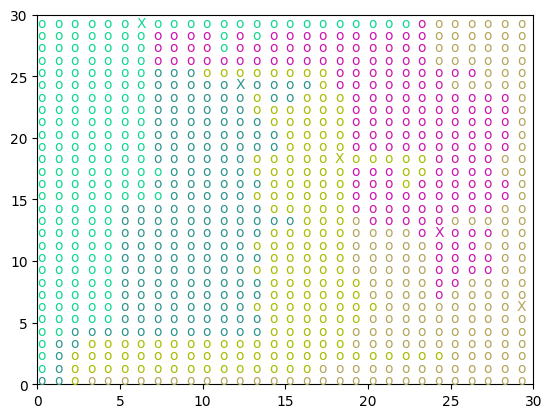

Number of democrat districts:  5.0


In [ ]:
n, D_map, R_map, K, C, D_Capitals = GenerateExample()

gerry_map, num_wins = Gerrymander_Opt(n, R_map,D_map,K,C, D_Capitals)

PlotSolution(gerry_map, D_map, R_map, D_Capitals)

print("Number of democrat districts: ", num_wins)
assert num_wins == 5

pops = [sum([D_map[l] + R_map[l] for l in  gerry_map if gerry_map[l]==k]) for k in range(K)]
for i in range(len(pops)):
    for j in range(i+1, len(pops)):
        if abs(pops[i] - pops[j]) > C:
            print("Population difference between districts %d and %d is not within C" %(i,j))
            print("Populations: ", pops[i], pops[j])
            assert False